## Author: Oliver Gladfelter
### June 25, 2026

## Part 1: Web Scraping

Collecting data on every Non-Playable Character on the wiki for a video game called Oldschool Runescape.

This will be a 2-step process:
1. Scrape category pages, which lists specific NPCs --> get a list of URLs for step 2
2. Iterate over list from above step, go to individual character pages, scrape character-level data

In [3]:
import lxml.html as lh
import io
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import os
import time
import json

## 1a. Prep - get a list of URL hrefs we will target

In [9]:
# "The following 200 pages are in this category, out of 4,443 total"
# I wrote a crawler

npc_pages = []
url = "https://oldschool.runescape.wiki/w/Category:Non-player_characters"
while url:
    npc_pages.append(url)
    soup = BeautifulSoup(requests.get(url).content, "lxml")
    next_link = soup.find('a', string='next page')
    url = "https://oldschool.runescape.wiki" + next_link['href'] if next_link else None
pd.Series(npc_pages).to_csv("npc_pages.csv", index=False, header=False)

In [10]:
# I need a helper function to really get started:

def scrapeCharactersFromPages(url):
    """
    We want data on NPCs. However, there are 1,449 NPCs we're targetting. 
    So let's start by getting the href for each of those 1,449 pages
    
    Param: URL to a category page, which will list 200 characters (or just 49, in the case of the last page)
    Return: list with href to each character listed on the page
    """
    r = requests.get(url)
    soup = BeautifulSoup(r.content, "lxml")

    character_url_suffixes = []

    categoryGroups = soup.findAll('div',{'class':'mw-category-group'})

    for categoryGroup in categoryGroups:
        listItems = categoryGroup.findAll('li')
        for listItem in listItems:
            a_tag = listItem.find('a')
            if a_tag and a_tag.get('href') and not a_tag['href'].startswith('/w/Category:'):
                character_url_suffixes.append(a_tag['href'])
       
    return character_url_suffixes

In [11]:
# now I can call this function on each of the pages included in npc_pages
# and save all the results to one list
npc_hrefs = []

for url in npc_pages:
    npc_hrefs.append(scrapeCharactersFromPages(url))
    
# flatten the list of lists we created
npc_hrefs_flat = [item for sublist in npc_hrefs for item in sublist]

# this should be over 4k
print(len(npc_hrefs_flat))

# first 3 look like dis
print(npc_hrefs_flat[0:3])

pd.Series(npc_hrefs_flat).to_csv("npc_hrefs_flat.csv", index=False, header=False)

4443
['/w/Non-player_character', '/w/1337mage43', '/w/1337sp34kr']


## 1b. Scrape data from each character page

One major road block: most the data we're interested in is placed in tables on each page. It's always a `<table>` with class="infobox", but the data is held in classless `<tr>`s. Pretty unhelpful. I'm thinking for each character page we can just grab the entire table (infobox) and create dataframes where each `<tr>`s `<th>` value is a column name and the corresponding `<td>` text is the value. Then we can concat all dataframes together for a final dataframe of 1,449 rows with a handful of columns but allowing for missing values.

In [12]:
# base URL
base = "https://oldschool.runescape.wiki" # we will append the character href (ex: '/w/Aberab') for the full URL

def get_character_soup(base, href):
    """
    helper function, returns soup for a specific character page (given the base and character href collected in step 1a)
    """
    character_url = base + href
    r = requests.get(character_url)
    soup = BeautifulSoup(r.content, "lxml")
    return soup

def parse_npc_infobox(soup):
    """
    there's so much inconsitency in these pages, so we're just grabbing:
        - character name
        - character coordinates
        - EVERYTHING in the info table (we'll clean this up in a subsequent step)
    """
    
    table = soup.find('table', {'class': 'infobox-npc'})
    if not table:
        return {}
    
    data = {}
    data['Name'] = table.find('th', {'class': 'infobox-header'}).get_text(strip=True)
    for row in table.find_all('tr'):
        th = row.find('th')
        td = row.find('td')
        if th and td:
            key = th.get_text(strip=True)
            val = td.get_text(' ', strip=True)  # space separator handles multi-link cells like "17 June 2002"
            data[key] = val
    
    # this will be fun...get the map coordinates for each character
    map_tag = table.find('a', {'class': 'mw-kartographer-map'})
    if map_tag: # I don't think every character has a map/coordinates on its page
        data['lat'] = map_tag.get('data-lat')
        data['lon'] = map_tag.get('data-lon')
    
    chathead_img = soup.find('img', src=re.compile(r'_chathead\.png'))
    data['chathead_url'] = base + chathead_img['src'].split('?')[0] if chathead_img else None

    body_img = soup.find('table', {'class': 'infobox-npc'}).find('img', src=re.compile(r'/images/thumb/'))
    data['body_url'] = base + re.sub(r'/thumb/(.+)/\d+px-.+$', r'/\1', body_img['src'].split('?')[0]) if body_img else None
    
    return data

Scraping 1,449 character pages...**can replace `npc_hrefs_flat` with `npc_hrefs_flat[0:50]` for a faster re-run**

In [13]:
# base URL
base = "https://oldschool.runescape.wiki" # we will append the character href (ex: '/w/Aberab') for the full URL

os.makedirs("chatheads", exist_ok=True)
os.makedirs("bodies", exist_ok=True)

characterData = []

for i, href in enumerate(npc_hrefs_flat):
    try:
        soup = get_character_soup(base, href)
        data = parse_npc_infobox(soup)
        data['id'] = i

        if data.get('chathead_url'):
            open(f"chatheads/{i}.png", 'wb').write(requests.get(data['chathead_url']).content)
        if data.get('body_url'):
            open(f"bodies/{i}.png", 'wb').write(requests.get(data['body_url']).content)
    except Exception as e:
        print(f"Failed on {href}: {e}")
        data = {'id': i}

    with open("npc.jsonl", "a") as f:
        f.write(json.dumps(data) + "\n")
    time.sleep(1)

characterData = [json.loads(line) for line in open("npc.jsonl")]
df = pd.DataFrame(characterData)
df.to_csv("npc.csv", index=False)

In [14]:
display(df.tail())

# 18 attributes on 1,449 records
print(len(df))
print(df.columns)

,id,Name,Released,Members,Race,Location,Leagueregion,Gender,Examine,NPC ID,...,Options,lat,lon,Quest,Removal,Shop,Also called,Combat level,Respawn time,Size
4438,4438,Zul-Gutusolly,8 January 2015 ( Update ),Yes,Gnome,Zul-Andra,Tirannwn ✓,Male,A worshipper of Zulrah.,2036,...,Talk-to,3049,2202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4439,4439,Zul-Onan,8 January 2015 ( Update ),Yes,Human,Zul-Andra,Tirannwn ✓,Male,The tribe's eel-catcher.,2038,...,Talk-to,3070,2189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4440,4440,Zul-Urgish,8 January 2015 ( Update ),Yes,Ogre,Zul-Andra,Tirannwn ✓,Male,Keeps order in the tribe's territory.,2034,...,Talk-to,3056,2200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4441,4441,Zuma,20 March 2024 ( Update ),Yes,Human,Outside Cam Torum . Upstairs in The Teomat (po...,Varlamore ✓,Male,A devout follower of Ranul.,13347,...,Talk-to,3195,1458,Perilous Moons,NaN,NaN,NaN,NaN,NaN,NaN
4442,4442,Fungi,7 March 2006 ( Update ),Yes,Fungi,Zanaris,General ✓,NaN,"A fun guy. No wait, that's awful. Plus it does...","533,535,538,637",...,Pick,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


4443
Index(['id', 'Name', 'Released', 'Members', 'Race', 'Location', 'Leagueregion',
       'Gender', 'Examine', 'NPC ID', 'Link', 'chathead_url', 'body_url',
       'Options', 'lat', 'lon', 'Quest', 'Removal', 'Shop', 'Also called',
       'Combat level', 'Respawn time', 'Size'],
      dtype='object')


## 1d. Data cleaning

- Convert `Removal` a boolean - most NPCs have not been removed
- Extract date of release from `Released`
- Standarize when necessary

In [ ]:
# I'm curious who got removed
df['removed'] = ~df['Removal'].isnull()

# ok better formatting for a timeline plot
df['Released'] = pd.to_datetime(df['Released'].str.extract(r'(\d+ \w+ \d{4})')[0], format='%d %B %Y')

# usually a missing attribute; 3 NPCs had 'No' (lol) and one had 3-126 (all the options, it varied)
df['Combat level'] = df['Combat level'].replace('No', np.nan)
df['Combat level'] = df['Combat level'].replace('3–126', np.nan)

# quite literally NOT a NPC!
df = df.drop('/w/Player_character')

In [ ]:
# ah, most of the removed NPCs were just added for temporary holiday events, makes sense
df[df['removed']].head(10)

## 1d. Data viz

### Timeline of cumulative NPC count. 

Rapid growth from 2000 to 2007 (game saved, kind of like a git branch lol; nothing until 2014 (this branch of the game is restored and development continues, albeit with an incredibly small dev team; slow growth for a while, but picking up pace in recent years as the dev team and game grows.

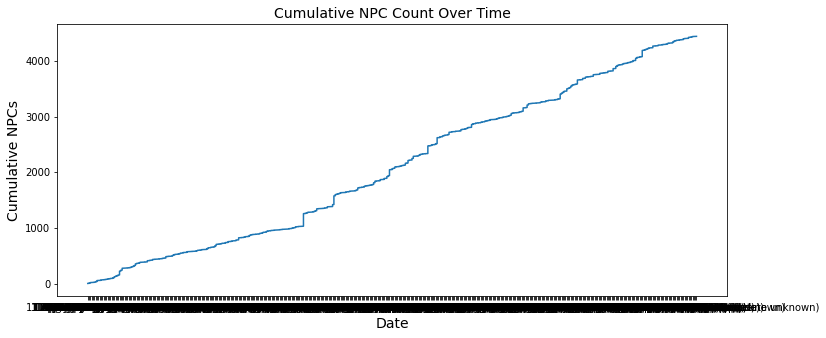

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = df.dropna(subset=['Released']).sort_values('Released').reset_index(drop=True).assign(cumulative=range(1, len(df.dropna(subset=['Released']))+1))
ax.plot(plot_df['Released'], plot_df['cumulative'])
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Cumulative NPCs', fontsize=14)
ax.set_title('Cumulative NPC Count Over Time', fontsize=14)
plt.show()

## Map of NPC locations

I grabbed an image of the map of the game's website. But need to match NPC coordinate with map image pixel coordinates. Used Claude to help with this.

In [17]:
# starting by creating a dictionary mapping 6 points I found both in the dataset and in the image
landmarks = {
    "al_kharid":  {"pixel": (4666, 2111), "game": (3302, 3163)},
    "lumbridge":  {"pixel": (4541, 2044), "game": (3228, 3206)},
    "varrock":    {"pixel": (4527, 1500), "game": (3222, 3472)},
    "farmers_guild": {"pixel": (575, 993),  "game": (1249, 3727)},
    "miscellenia":   {"pixel": (3079, 728),  "game": (2501, 3861)},
    "ape_atoll":     {"pixel": (3685, 2920), "game": (2803, 2765)},
}

# performing coordinate to pixel transformation
pts_game  = np.array([v["game"]  for v in landmarks.values()])
pts_pixel = np.array([v["pixel"] for v in landmarks.values()])

# Build A matrix: [x, y, 1] for each point
A = np.column_stack([pts_game, np.ones(len(pts_game))])

# Solve for coefficients separately for px_x and px_y
cx, _, _, _ = np.linalg.lstsq(A, pts_pixel[:, 0], rcond=None)
cy, _, _, _ = np.linalg.lstsq(A, pts_pixel[:, 1], rcond=None)

def game_to_pixel(gx, gy):
    return (
        cx[0]*gx + cx[1]*gy + cx[2],
        cy[0]*gx + cy[1]*gy + cy[2],
    )

def in_bounds(gx, gy):
    """
    Many coordinates of NPCs in dungeons or 'other dimensions' (idk video games can get weird)
    fall outside the map's boundaries. We wanna focus on the 'surface world' - whatever is visible in the map.
    """
    px, py = game_to_pixel(gx, gy)
    return 0 <= px <= img_w and 0 <= py <= img_h

0.5151924375422012


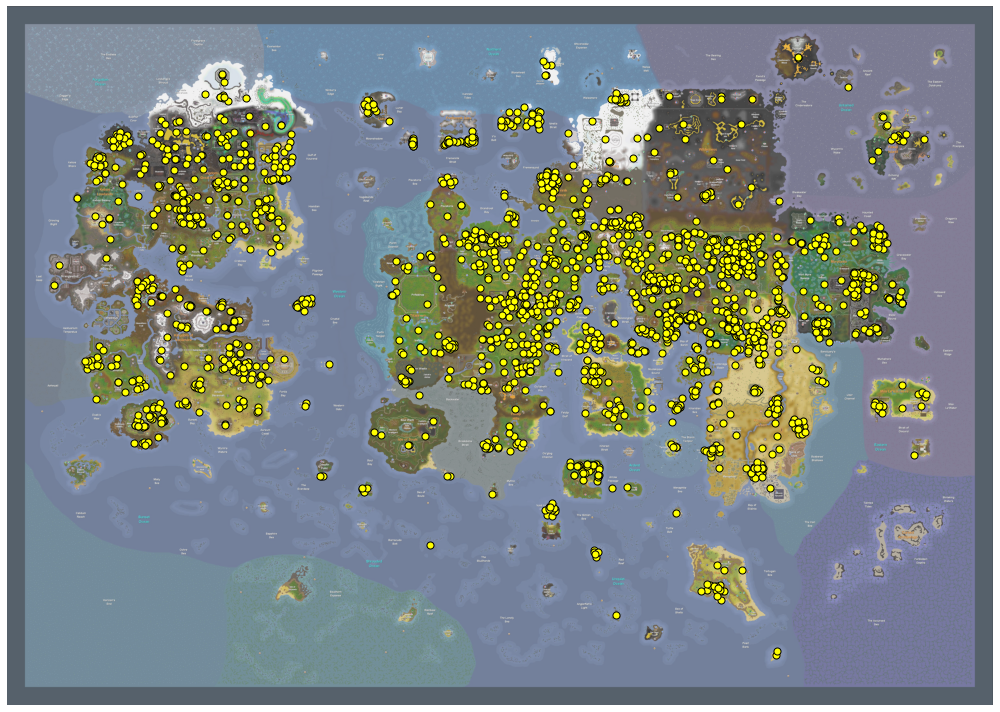

In [21]:
# ok ready to plot!!
img = mpimg.imread("osrs_world_map.jpg")
img_h, img_w = img.shape[:2] # needed for removing characters outside the surface world

fig, ax = plt.subplots(figsize=(16, 10))
ax.imshow(img, alpha = 0.8)

# NPC coordinate data
characters_with_coords = df.dropna(subset=['lat', 'lon'])
surface_characters = characters_with_coords[characters_with_coords.apply(lambda r: in_bounds(float(r['lon']), float(r['lat'])), axis=1)]
print(len(surface_characters) / len(df)) # what % survived our filtering?

npc_coords = list(zip(surface_characters['lon'].astype(float), surface_characters['lat'].astype(float)))

for gx, gy in npc_coords:
    px, py = game_to_pixel(gx, gy)
    ax.scatter(px, py, c='yellow', s=50, linewidths=1, edgecolors='black')

ax.axis('off')
plt.tight_layout()
plt.savefig("osrs_npc_map.png", dpi=150, bbox_inches='tight') # saving it so I can send to my friends lol
plt.show()